# hij-subset metrics plot

This notebook loads a `metrics.jsonl` file produced by the hij-subset run and plots:
- Train step loss (with optional smoothing)
- Train epoch loss
- Val/Test MSE over epochs

Edit the config cell below to point at your run.

In [ ]:
from pathlib import Path
import subprocess, shlex

REMOTE_USER = 'ec2-user'
REMOTE_HOST = '<HERE>'
SSH_KEY = str(Path('~/<HERE>').expanduser())
LOCAL_METRICS = Path('artifacts/hij-subset-metrics.jsonl')
LOCAL_METRICS.parent.mkdir(parents=True, exist_ok=True)

find_cmd = 'ls -dt /fsx/model_registry/hij-subset/hij-subset-_trainable_* /fsx/model_registry/hij-subset-_trainable_* 2>/dev/null | head -n 1'
ssh_cmd = ['ssh', '-i', SSH_KEY, f'{REMOTE_USER}@{REMOTE_HOST}', find_cmd]
REMOTE_RUN_DIR = subprocess.check_output(ssh_cmd, text=True).strip()

print('REMOTE_RUN_DIR =', REMOTE_RUN_DIR)

remote_path = f'{REMOTE_USER}@{REMOTE_HOST}:{REMOTE_RUN_DIR}/metrics.jsonl'
if LOCAL_METRICS.exists():
    LOCAL_METRICS.unlink()
subprocess.run(['scp', '-i', SSH_KEY, remote_path, str(LOCAL_METRICS)], check=True)

print('Using metrics:', LOCAL_METRICS)


REMOTE_RUN_DIR = /fsx/model_registry/hij-subset/hij-subset-_trainable_77616_00000
Using metrics: artifacts/hij-subset-metrics.jsonl


In [2]:
import json
import pandas as pd
from IPython.display import display

rows = []
with LOCAL_METRICS.open() as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df = df.sort_values(['epoch', 'step'], kind='stable').reset_index(drop=True)

# Split the heterogeneous rows so we avoid NaNs when inspecting tables
train_step = df[df.get('split') == 'train'][['epoch', 'step', 'loss', 'lr']].copy()
train_epoch = df[df.get('train_loss_epoch').notna()][['epoch', 'step', 'train_loss_epoch', 'train_mse_epoch', 'lr', 'skipped_batches']].copy()
eval_epoch = df[df.get('val_mse').notna()][['epoch', 'step', 'val_mse', 'val_mae', 'test_mse', 'test_mae']].copy()

print('rows:', len(df), 'train_step:', len(train_step), 'train_epoch:', len(train_epoch), 'eval:', len(eval_epoch))
display(train_step.head())
display(train_epoch.head())
display(eval_epoch.head())


rows: 33 train_step: 13 train_epoch: 20 eval: 10


,epoch,step,loss,lr
0,0,10,11.606129,0.001000
3,1,20,8.416726,0.000976
6,2,30,4.565561,0.000905
9,3,40,1.424766,0.000794
10,3,50,9.818442,0.000794


,epoch,step,train_loss_epoch,train_mse_epoch,lr,skipped_batches
1,0,13,16.258883,16.258883,0.000976,0.0
2,0,13,16.258883,16.258883,NaN,NaN
4,1,26,16.122934,16.122934,0.000905,0.0
5,1,26,16.122934,16.122934,NaN,NaN
7,2,39,15.541613,15.541613,0.000794,0.0


,epoch,step,val_mse,val_mae,test_mse,test_mae
2,0,13,15.119944,1.285639,13.832335,1.257515
5,1,26,15.390845,1.299902,15.972262,1.280249
8,2,39,17.124409,1.194335,13.787112,1.201224
12,3,52,11.320100,1.136988,13.060508,1.154086
15,4,65,9.419126,1.048502,9.716232,1.030498


In [3]:
df

,epoch,step,split,loss,lr,train_loss_epoch,train_mse_epoch,skipped_batches,val_mse,val_mse_lo,val_mse_hi,val_mae,val_mae_lo,val_mae_hi,test_mse,test_mse_lo,test_mse_hi,test_mae,test_mae_lo,test_mae_hi
0,0,10,train,11.606129,0.001000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,13,train_epoch,NaN,0.000976,16.258883,16.258883,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,13,NaN,NaN,NaN,16.258883,16.258883,NaN,15.119944,13.558760,16.694262,1.285639,1.237342,1.333175,13.832335,12.405701,15.549982,1.257515,1.204001,1.303865
3,1,20,train,8.416726,0.000976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,26,train_epoch,NaN,0.000905,16.122934,16.122934,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,26,NaN,NaN,NaN,16.122934,16.122934,NaN,15.390845,13.936379,17.067335,1.299902,1.251950,1.358403,15.972262,13.361712,18.764690,1.280249,1.239493,1.336205
6,2,30,train,4.565561,0.000905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2,39,train_epoch,NaN,0.000794,15.541613,15.541613,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2,39,NaN,NaN,NaN,15.541613,15.541613,NaN,17.124409,14.180089,20.748890,1.194335,1.153712,1.239614,13.787112,12.290684,15.378041,1.201224,1.150396,1.246771
9,3,40,train,1.424766,0.000794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Quick sanity counts
print('rows:', len(df))
print('train step rows:', (df.get('split') == 'train').sum())
print('train epoch rows:', df.get('train_loss_epoch').notna().sum())
print('val rows:', df.get('val_mse').notna().sum())


rows: 33
train step rows: 13
train epoch rows: 20
val rows: 10


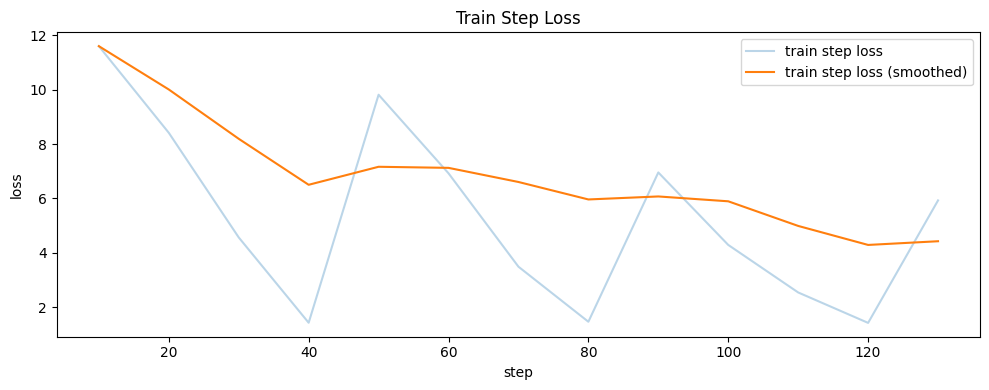

In [5]:
import matplotlib.pyplot as plt

train_step = df[df.get('split') == 'train'].copy()
if not train_step.empty:
    train_step['loss_smooth'] = train_step['loss'].rolling(10, min_periods=1).mean()

plt.figure(figsize=(10, 4))
if not train_step.empty:
    plt.plot(train_step['step'], train_step['loss'], alpha=0.3, label='train step loss')
    plt.plot(train_step['step'], train_step['loss_smooth'], label='train step loss (smoothed)')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Train Step Loss')
plt.legend()
plt.tight_layout()
plt.show()


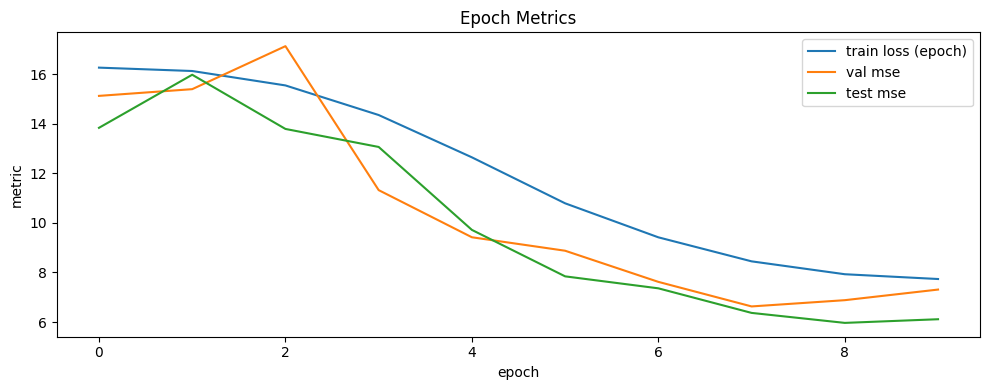

In [6]:
# Epoch-level metrics
train_epoch = df[df.get('train_loss_epoch').notna()].copy()
train_epoch = train_epoch.sort_values('epoch').groupby('epoch', as_index=False).last()

val_epoch = df[df.get('val_mse').notna()].copy()
val_epoch = val_epoch.sort_values('epoch').groupby('epoch', as_index=False).last()

plt.figure(figsize=(10, 4))
if not train_epoch.empty:
    plt.plot(train_epoch['epoch'], train_epoch['train_loss_epoch'], label='train loss (epoch)')
if not val_epoch.empty:
    plt.plot(val_epoch['epoch'], val_epoch['val_mse'], label='val mse')
    plt.plot(val_epoch['epoch'], val_epoch['test_mse'], label='test mse')
plt.xlabel('epoch')
plt.ylabel('metric')
plt.title('Epoch Metrics')
plt.legend()
plt.tight_layout()
plt.show()
